# LoFTR inference demo

This notebook demonstrates the inference pipeline for satellite image
matching using the pretrained LoFTR model.


In [ ]:
CONFIDENCE_THRESHOLD = 0.8

TOP_K = 100

PAIR_INDEX = 0

pair = sorted(Path("/prepared_dataset").iterdir())[PAIR_INDEX]

imageA_path = pair / "image_A.jp2"
imageB_path = pair / "image_B.jp2"

## Running the matching algorithm

The prepared Sentinel-2 image pair is processed using the proposed matching pipeline.

The algorithm performs the following steps internally:

- loads the jp2 images;
- splits each image into 1024 × 1024 tiles;
- matches corresponding tiles using the pretrained LoFTR model;
- converts local tile coordinates into global image coordinates;
- merges all detected correspondences.

In [27]:
imgA, imgB, kp0, kp1, conf = run_matching(imageA_path, imageB_path, tile_size = 1024)

Matching image tiles: 100%|██████████| 100/100 [2:14:50<00:00, 80.90s/it]


## Filtering correspondences

The pretrained LoFTR model returns all detected correspondences together
with their confidence scores.

To improve visualization, correspondences with confidence below the
selected threshold are discarded. Finally, only **TOP_K**
matches are retained.

In [29]:
kp0, kp1, conf = filter_matches(kp0, kp1, conf, CONFIDENCE_THRESHOLD, TOP_K)

## Visualizing image matches

The remaining correspondences are visualized.

The two Sentinel-2 images are displayed side by side, while colored lines connect the matched keypoints.

The line color represents the confidence score of each correspondence.

### Example 1 — Pair 0 (Winter to Summer)

The first example shows image matching between two Sentinel-2 images
acquired on 12 February 2016 and 30 August 2016.


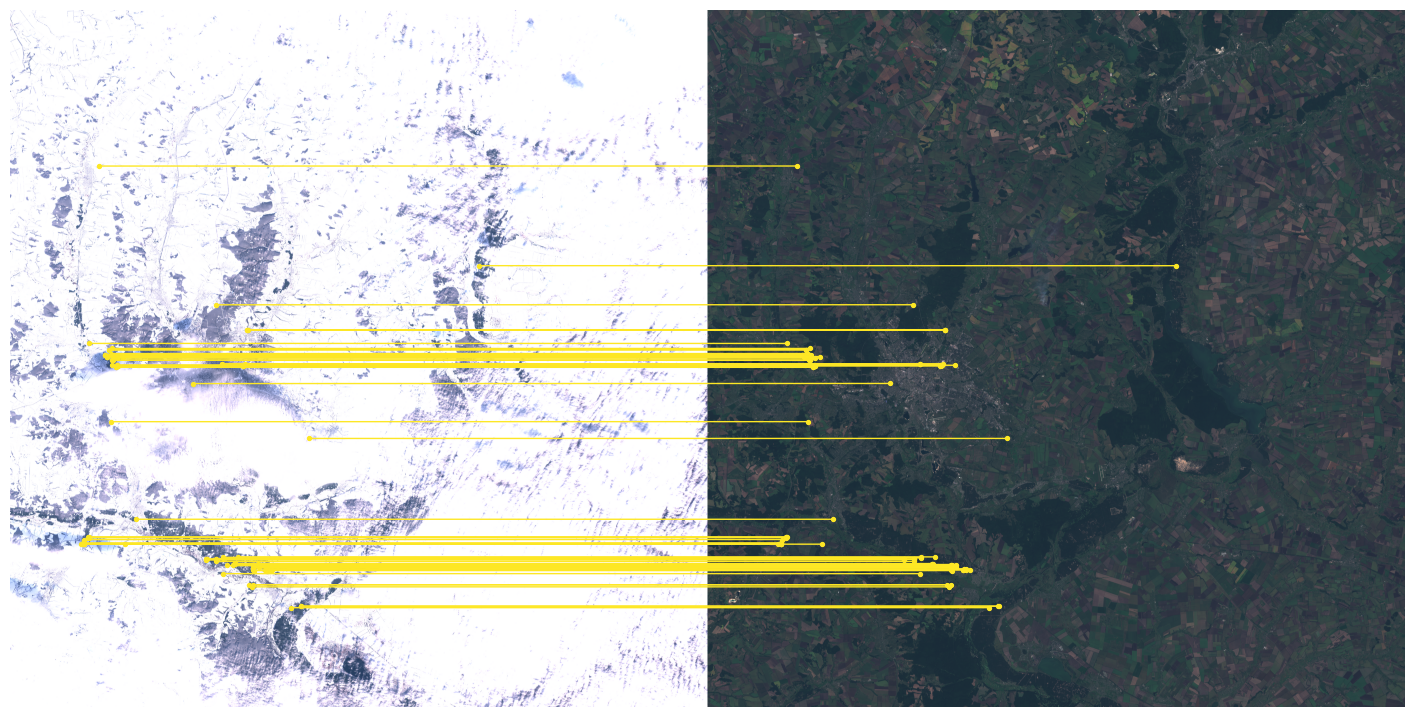

In [30]:
visualize_matches(imgA, imgB, kp0, kp1, conf)

### Example 2 — Pair 15 (Spring to Summer)

The second example shows image matching between two Sentinel-2 images
acquired on 13 March 2019 and 15 August 2019.

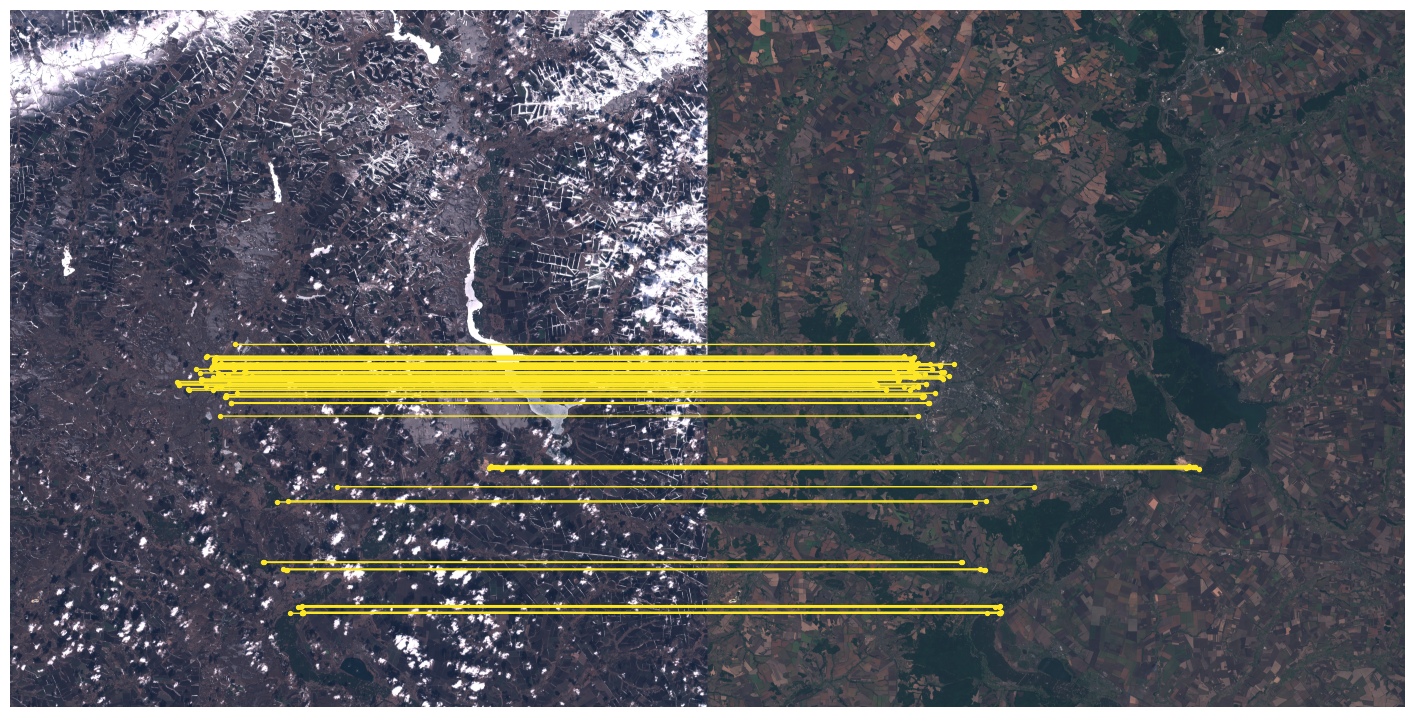

In [ ]:
visualize_matches(img1A, img1B, mkpts_0, mkpts_1, confidence1)